In [2]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"C:\Users\cmkua\Downloads\ALANA\127.xlsx"

df = pd.read_excel(path)


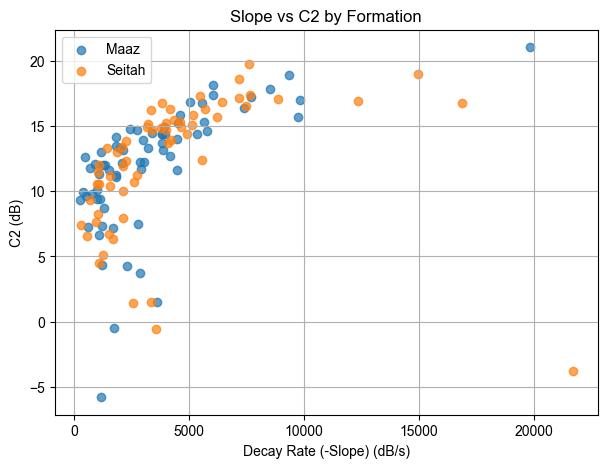

In [4]:
# ============================================================
# SLOPE VS C2 BY FORMATION
# ============================================================

maaz = df[df["Formation"] == "Maaz"]
seitah = df[df["Formation"] == "Seitah"]

plt.figure(figsize=(7, 5))

plt.scatter(
    -maaz["Slope (dB/s)"],
    maaz["C2 (dB)"],
    label="Maaz",
    alpha=0.7
)

plt.scatter(
    -seitah["Slope (dB/s)"],
    seitah["C2 (dB)"],
    label="Seitah",
    alpha=0.7
)

plt.xlabel("Decay Rate (-Slope) (dB/s)")
plt.ylabel("C2 (dB)")
plt.title("Slope vs C2 by Formation")

plt.legend()

plt.grid(True)

plt.show()

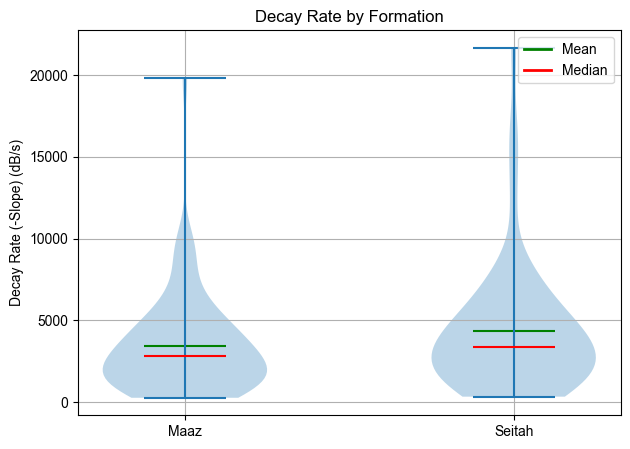

In [5]:
# ============================================================
# VIOLIN PLOT: DECAY RATE BY FORMATION
# ============================================================

maaz = df[df["Formation"] == "Maaz"]
seitah = df[df["Formation"] == "Seitah"]

fig, ax = plt.subplots(figsize=(7, 5))

parts = ax.violinplot(
    [
        -maaz["Slope (dB/s)"],
        -seitah["Slope (dB/s)"]
    ],
    showmeans=True,
    showmedians=True
)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Maaz", "Seitah"])

ax.set_ylabel("Decay Rate (-Slope) (dB/s)")
ax.set_title("Decay Rate by Formation")

# ------------------------------------------------------------
# COLOR MEAN + MEDIAN
# ------------------------------------------------------------

parts['cmeans'].set_color('green')
parts['cmedians'].set_color('red')

# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------

from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0],
        [0],
        color='green',
        lw=2,
        label='Mean'
    ),
    Line2D(
        [0],
        [0],
        color='red',
        lw=2,
        label='Median'
    )
]

ax.legend(handles=legend_elements)

ax.grid(True)

plt.show()

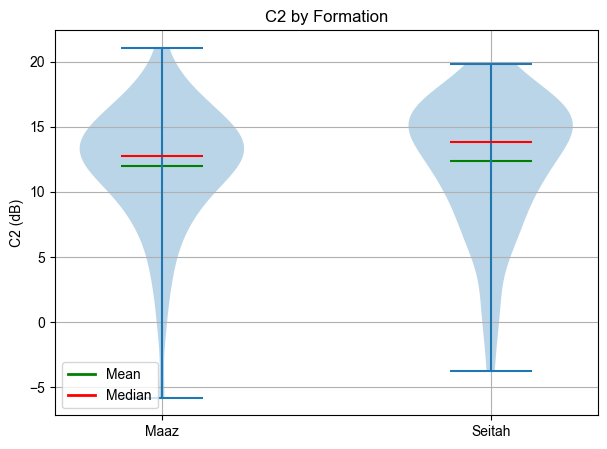

In [6]:
# ============================================================
# VIOLIN PLOT: C2 BY FORMATION
# ============================================================

maaz = df[df["Formation"] == "Maaz"]
seitah = df[df["Formation"] == "Seitah"]

fig, ax = plt.subplots(figsize=(7, 5))

parts = ax.violinplot(
    [
        maaz["C2 (dB)"],
        seitah["C2 (dB)"]
    ],
    showmeans=True,
    showmedians=True
)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Maaz", "Seitah"])

ax.set_ylabel("C2 (dB)")
ax.set_title("C2 by Formation")

# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------

from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0],
        [0],
        color='green',
        lw=2,
        label='Mean'
    ),
    Line2D(
        [0],
        [0],
        color='red',
        lw=2,
        label='Median'
    )
]

# Color mean and median lines
parts['cmeans'].set_color('green')
parts['cmedians'].set_color('red')

ax.legend(handles=legend_elements)

ax.grid(True)

plt.show()

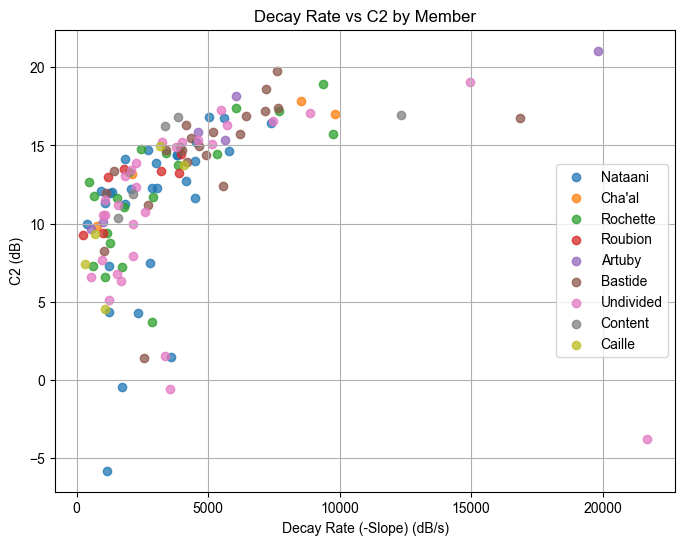

In [7]:
# ============================================================
# SCATTERPLOT: DECAY RATE VS C2 BY MEMBER
# ============================================================

plt.figure(figsize=(8, 6))

for member in df["Member"].dropna().unique():
    subset = df[df["Member"] == member]

    plt.scatter(
        -subset["Slope (dB/s)"],
        subset["C2 (dB)"],
        label=member,
        alpha=0.75
    )

plt.xlabel("Decay Rate (-Slope) (dB/s)")
plt.ylabel("C2 (dB)")
plt.title("Decay Rate vs C2 by Member")

plt.legend()
plt.grid(True)

plt.show()

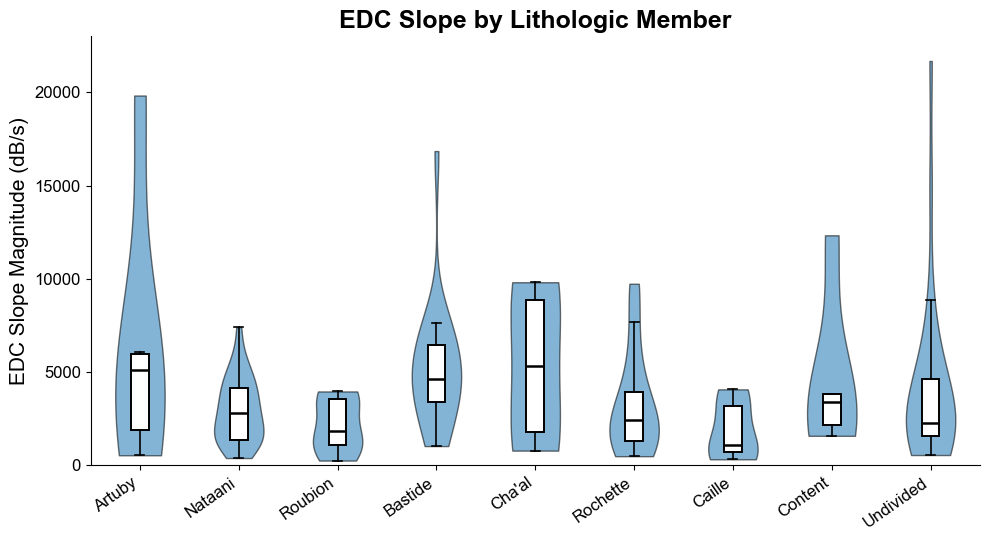

In [9]:
# ============================================================
# VIOLIN PLOT: EDC SLOPE BY LITHOLOGIC MEMBER
# ============================================================
import matplotlib.pyplot as plt
# Optional: set poster font
plt.rcParams["font.family"] = "Arial"

# Order members by expected porosity grouping if desired
member_order = [
    "Artuby",
    "Nataani",
    "Roubion",
    "Bastide",
    "Cha'al",
    "Rochette",
    "Caille",
    "Content",
    "Undivided"
]

members = [
    member for member in member_order
    if member in df["Member"].dropna().unique()
]

data = [
    -df[df["Member"] == member]["Slope (dB/s)"].dropna()
    for member in members
]

fig, ax = plt.subplots(figsize=(10, 5.5))

parts = ax.violinplot(
    data,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Clean violin styling
for body in parts["bodies"]:
    body.set_alpha(0.55)
    body.set_edgecolor("black")
    body.set_linewidth(1)

# Add simple boxplot overlay
ax.boxplot(
    data,
    widths=0.18,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.4),
    medianprops=dict(color="black", linewidth=1.8),
    whiskerprops=dict(color="black", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2)
)

ax.set_xticks(range(1, len(members) + 1))
ax.set_xticklabels(
    members,
    rotation=35,
    ha="right",
    fontsize=12
)

ax.set_ylabel(
    "EDC Slope Magnitude (dB/s)",
    fontsize=15
)

ax.set_title(
    "EDC Slope by Lithologic Member",
    fontsize=18,
    weight="bold"
)

ax.tick_params(axis="y", labelsize=12)

# Clean poster formatting
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# Add headroom so violins are not clipped
ax.set_ylim(0, 23000)
plt.tight_layout()

plt.savefig(
    "poster_edc_slope_by_member.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "poster_edc_slope_by_member.pdf",
    bbox_inches="tight"
)

plt.show()

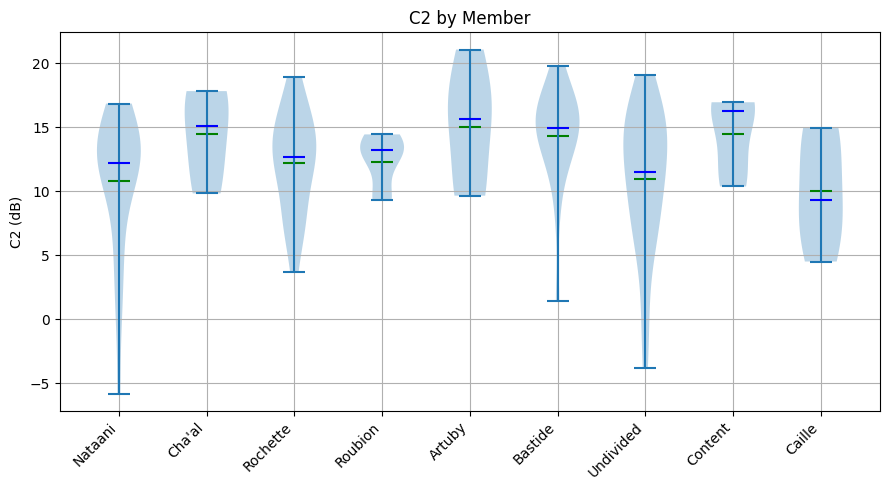

In [37]:
# ============================================================
# VIOLIN PLOT: C2 BY MEMBER
# ============================================================

members = df["Member"].dropna().unique()

data = [
    df[df["Member"] == member]["C2 (dB)"]
    for member in members
]

fig, ax = plt.subplots(figsize=(9, 5))

parts = ax.violinplot(
    data,
    showmeans=True,
    showmedians=True
)

ax.set_xticks(range(1, len(members) + 1))
ax.set_xticklabels(members, rotation=45, ha="right")

ax.set_ylabel("C2 (dB)")
ax.set_title("C2 by Member")

parts["cmeans"].set_color("green")
parts["cmedians"].set_color("blue")

ax.grid(True)

plt.tight_layout()
plt.show()

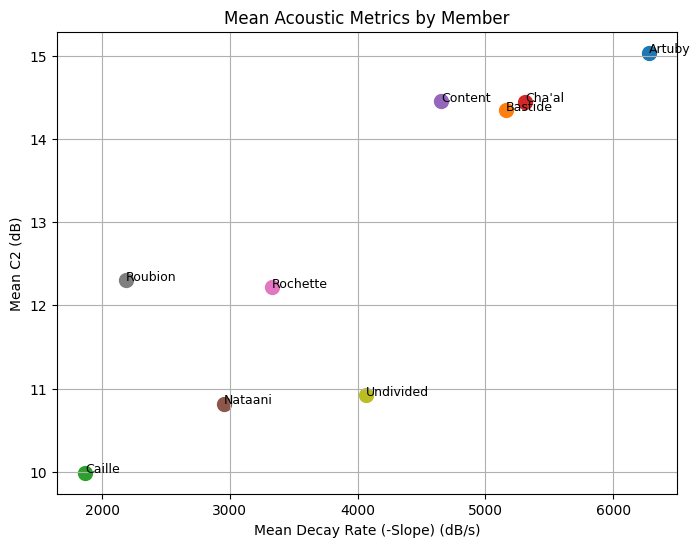

In [38]:
# ============================================================
# MEMBER MEAN SCATTERPLOT
# ============================================================

member_means = (
    df.groupby("Member")
    .agg({
        "Slope (dB/s)": "mean",
        "C2 (dB)": "mean"
    })
    .reset_index()
)

plt.figure(figsize=(8, 6))

for _, row in member_means.iterrows():

    x = -row["Slope (dB/s)"]
    y = row["C2 (dB)"]

    plt.scatter(x, y, s=100)

    plt.text(
        x,
        y,
        row["Member"],
        fontsize=9
    )

plt.xlabel("Mean Decay Rate (-Slope) (dB/s)")
plt.ylabel("Mean C2 (dB)")
plt.title("Mean Acoustic Metrics by Member")

plt.grid(True)

plt.show()

In [42]:
# ============================================================
# SUMMARY TABLE BY MEMBER
# ============================================================

summary = (
    df.groupby("Member")
    .agg(
        Count=("Member", "size"),
        Mean_Decay_Rate=("Slope (dB/s)", lambda x: (-x).mean()),
        Std_Decay_Rate=("Slope (dB/s)", lambda x: (-x).std()),
        Mean_C2=("C2 (dB)", "mean"),
        Std_C2=("C2 (dB)", "std")
    )
    .reset_index()
)

summary = summary.sort_values(
    by="Mean_Decay_Rate"
).reset_index(drop=True)

summary

# ============================================================
# ADD EXPECTED POROSITY TO SUMMARY TABLE
# ============================================================

porosity_map = {
    "Artuby": "Low",
    "Cha'al": "High",
    "Nataani": "Low",
    "Rochette": "High",
    "Roubion": "Low",
    "Caille": "High",
    "Content": "High",
    "Bastide": "Low",
    "Undivided": "Low"
}

summary["Expected Porosity"] = summary["Member"].map(porosity_map)

# Optional: reorder columns
summary = summary[
    [
        "Member",
        "Expected Porosity",
        "Count",
        "Mean_Decay_Rate",
        "Std_Decay_Rate",
        "Mean_C2",
        "Std_C2"
    ]
]

summary

,Member,Expected Porosity,Count,Mean_Decay_Rate,Std_Decay_Rate,Mean_C2,Std_C2
0,Caille,High,5,1867.400737,1655.194550,9.988187,4.352859
1,Roubion,Low,7,2185.322271,1489.711372,12.304911,2.076178
2,Nataani,Low,29,2954.051940,1728.001222,10.817674,5.425094
3,Rochette,High,21,3330.409660,2792.499423,12.215620,3.950131
4,Undivided,Low,29,4066.820173,4518.814296,10.917709,5.554405
5,Content,High,5,4653.170580,4387.997670,14.454858,3.089643
6,Bastide,Low,21,5160.603205,3371.673106,14.343985,3.953187
7,Cha'al,High,4,5312.684944,4522.585937,14.448534,3.688433
8,Artuby,Low,6,6280.145525,7036.039872,15.035770,4.469835


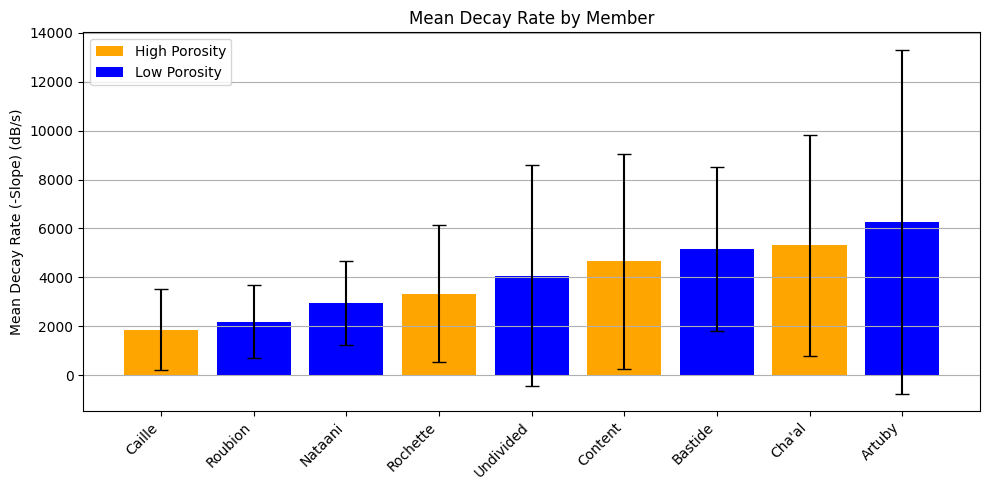

In [43]:
# ============================================================
# BAR CHART: MEAN DECAY RATE BY MEMBER
# ============================================================

import matplotlib.pyplot as plt

# Sort by decay rate
plot_df = summary.sort_values(
    by="Mean_Decay_Rate"
).reset_index(drop=True)

# Color by porosity
colors = plot_df["Expected Porosity"].map({
    "High": "orange",
    "Low": "blue"
})

plt.figure(figsize=(10, 5))

plt.bar(
    plot_df["Member"],
    plot_df["Mean_Decay_Rate"],
    yerr=plot_df["Std_Decay_Rate"],
    color=colors,
    capsize=5
)

plt.ylabel("Mean Decay Rate (-Slope) (dB/s)")
plt.title("Mean Decay Rate by Member")

plt.xticks(rotation=45, ha="right")

# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="orange", label="High Porosity"),
    Patch(facecolor="blue", label="Low Porosity")
]

plt.legend(handles=legend_elements)

plt.grid(True, axis="y")

plt.tight_layout()
plt.show()

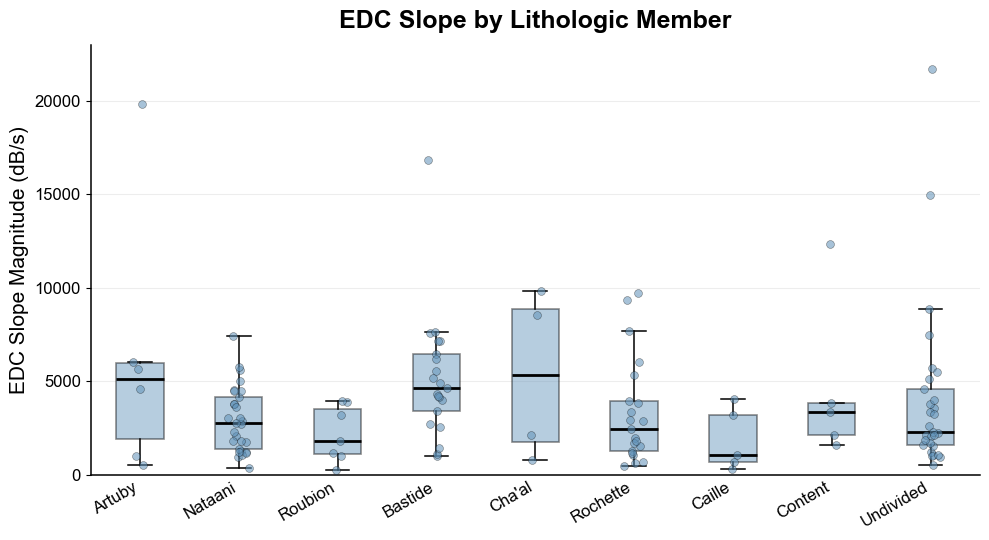

In [15]:
# ============================================================
# CLEAN BOXPLOT + JITTERED POINTS: EDC SLOPE BY MEMBER
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"

# Reproducible jitter
np.random.seed(4)

member_order = [
    "Artuby",
    "Nataani",
    "Roubion",
    "Bastide",
    "Cha'al",
    "Rochette",
    "Caille",
    "Content",
    "Undivided"
]

members = [
    member for member in member_order
    if member in df["Member"].dropna().unique()
]

data = [
    -df[df["Member"] == member]["Slope (dB/s)"].dropna()
    for member in members
]

fig, ax = plt.subplots(figsize=(10, 5.5))

main_color = "#5f91b8"

bp = ax.boxplot(
    data,
    patch_artist=True,
    widths=0.48,
    showfliers=False
)

# Box styling
for box in bp["boxes"]:
    box.set(
        facecolor=main_color,
        edgecolor="black",
        linewidth=1.2,
        alpha=0.45
    )

for median in bp["medians"]:
    median.set(
        color="black",
        linewidth=2
    )

for whisker in bp["whiskers"]:
    whisker.set(
        color="black",
        linewidth=1.1
    )

for cap in bp["caps"]:
    cap.set(
        color="black",
        linewidth=1.1
    )

# Jittered points
for i, y in enumerate(data, start=1):
    x = np.random.normal(i, 0.045, size=len(y))

    ax.scatter(
        x,
        y,
        s=32,
        color=main_color,
        alpha=0.55,
        edgecolor="black",
        linewidth=0.35,
        zorder=3
    )

# Labels + formatting
ax.set_xticks(range(1, len(members) + 1))

ax.set_xticklabels(
    members,
    rotation=30,
    ha="right",
    fontsize=12
)

ax.set_ylabel(
    "EDC Slope Magnitude (dB/s)",
    fontsize=15
)

ax.set_title(
    "EDC Slope by Lithologic Member",
    fontsize=18,
    weight="bold",
    pad=12
)

ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", length=0)

# Subtle horizontal grid only
ax.grid(
    axis="y",
    alpha=0.22,
    linewidth=0.8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.1)
ax.spines["bottom"].set_linewidth(1.1)

ax.set_ylim(0, 23000)

plt.tight_layout()

plt.savefig(
    "poster_edc_slope_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "poster_edc_slope_boxplot.pdf",
    bbox_inches="tight"
)

plt.show()

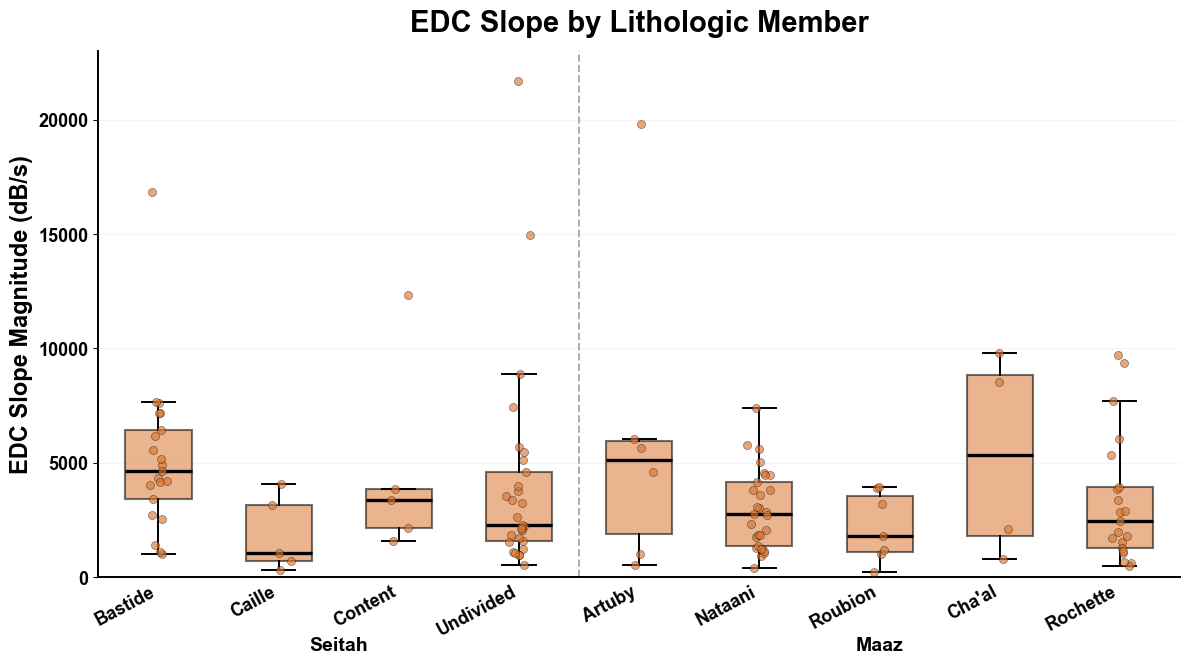

In [5]:
# ============================================================
# CLEAN BOXPLOT + JITTERED POINTS: EDC SLOPE BY MEMBER
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

np.random.seed(4)

member_order = [
    # Seitah
    "Bastide",
    "Caille",
    "Content",
    "Undivided",

    # Maaz
    "Artuby",
    "Nataani",
    "Roubion",
    "Cha'al",
    "Rochette"
]

members = [
    member for member in member_order
    if member in df["Member"].dropna().unique()
]

data = [
    -df[df["Member"] == member]["Slope (dB/s)"].dropna()
    for member in members
]

# Enlarged plot
fig, ax = plt.subplots(figsize=(12, 6.6))

main_color = "#d97732"

bp = ax.boxplot(
    data,
    patch_artist=True,
    widths=0.55,
    showfliers=False
)

for box in bp["boxes"]:
    box.set(
        facecolor=main_color,
        edgecolor="black",
        linewidth=1.5,
        alpha=0.55
    )

for median in bp["medians"]:
    median.set(color="black", linewidth=2.4)

for whisker in bp["whiskers"]:
    whisker.set(color="black", linewidth=1.4)

for cap in bp["caps"]:
    cap.set(color="black", linewidth=1.4)

for i, y in enumerate(data, start=1):
    x = np.random.normal(i, 0.045, size=len(y))

    ax.scatter(
        x,
        y,
        s=34,
        color=main_color,
        alpha=0.65,
        edgecolor="black",
        linewidth=0.35,
        zorder=3
    )

ax.set_xticks(range(1, len(members) + 1))

ax.set_xticklabels(
    members,
    rotation=28,
    ha="right",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "EDC Slope Magnitude (dB/s)",
    fontsize=17,
    fontweight="bold"
)

ax.set_title(
    "EDC Slope by Lithologic Member",
    fontsize=21,
    weight="bold",
    pad=14
)

# Formation labels
ax.text(
    2.5,
    -0.14,
    "Seitah",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize=14,
    weight="bold",
    color="black"
)

ax.text(
    7,
    -0.14,
    "Maaz",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize=14,
    weight="bold",
    color="black"
)

# Divider between formations
ax.axvline(
    4.5,
    color="gray",
    linestyle="--",
    linewidth=1.4,
    alpha=0.65
)

ax.tick_params(axis="y", labelsize=13)
ax.tick_params(axis="x", length=0)

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.grid(
    axis="y",
    alpha=0.13,
    linewidth=0.75
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.4)
ax.spines["bottom"].set_linewidth(1.4)

ax.set_ylim(0, 23000)

plt.subplots_adjust(bottom=0.25)
plt.tight_layout()

plt.savefig(
    "poster_edc_slope_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "poster_edc_slope_boxplot.pdf",
    bbox_inches="tight"
)

plt.show()

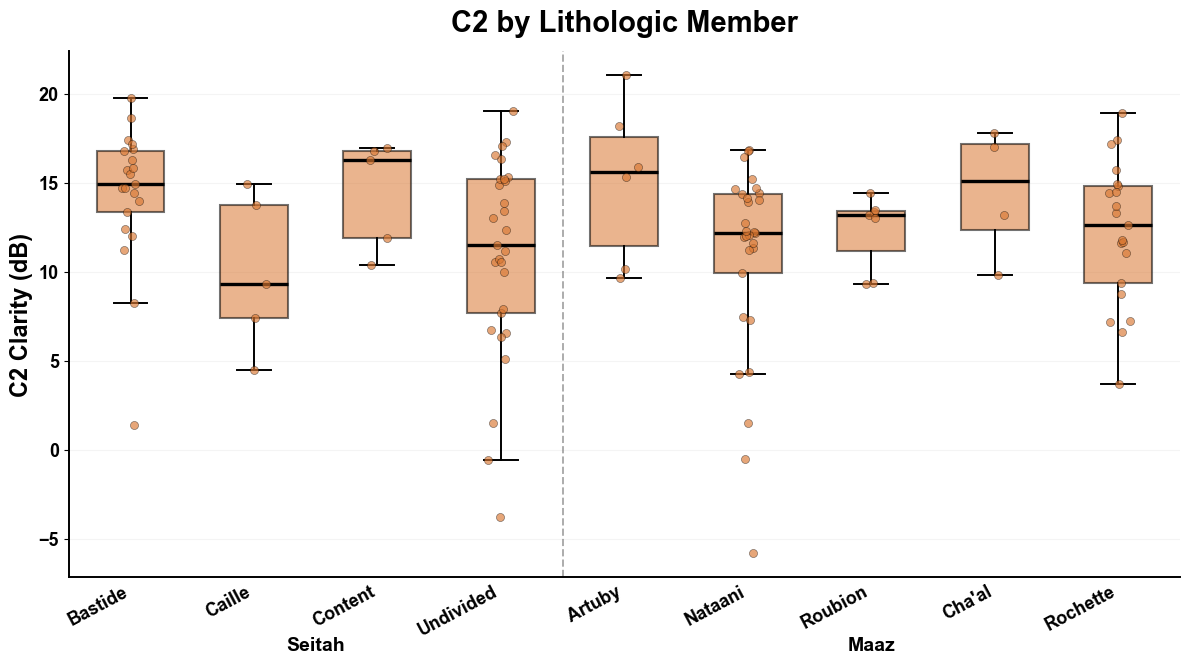

In [6]:
# ============================================================
# CLEAN BOXPLOT + JITTERED POINTS: C2 BY MEMBER
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

np.random.seed(4)

member_order = [
    # Seitah
    "Bastide",
    "Caille",
    "Content",
    "Undivided",

    # Maaz
    "Artuby",
    "Nataani",
    "Roubion",
    "Cha'al",
    "Rochette"
]

members = [
    member for member in member_order
    if member in df["Member"].dropna().unique()
]

data = [
    df[df["Member"] == member]["C2 (dB)"].dropna()
    for member in members
]

# Enlarged plot
fig, ax = plt.subplots(figsize=(12, 6.6))

main_color = "#d97732"

bp = ax.boxplot(
    data,
    patch_artist=True,
    widths=0.55,
    showfliers=False
)

for box in bp["boxes"]:
    box.set(
        facecolor=main_color,
        edgecolor="black",
        linewidth=1.5,
        alpha=0.55
    )

for median in bp["medians"]:
    median.set(color="black", linewidth=2.4)

for whisker in bp["whiskers"]:
    whisker.set(color="black", linewidth=1.4)

for cap in bp["caps"]:
    cap.set(color="black", linewidth=1.4)

for i, y in enumerate(data, start=1):
    x = np.random.normal(i, 0.045, size=len(y))

    ax.scatter(
        x,
        y,
        s=34,
        color=main_color,
        alpha=0.65,
        edgecolor="black",
        linewidth=0.35,
        zorder=3
    )

ax.set_xticks(range(1, len(members) + 1))

ax.set_xticklabels(
    members,
    rotation=28,
    ha="right",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "C2 Clarity (dB)",
    fontsize=17,
    fontweight="bold"
)

ax.set_title(
    "C2 by Lithologic Member",
    fontsize=21,
    weight="bold",
    pad=14
)

# Formation labels
ax.text(
    2.5,
    -0.14,
    "Seitah",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize=14,
    weight="bold",
    color="black"
)

ax.text(
    7,
    -0.14,
    "Maaz",
    transform=ax.get_xaxis_transform(),
    ha="center",
    fontsize=14,
    weight="bold",
    color="black"
)

# Divider between formations
ax.axvline(
    4.5,
    color="gray",
    linestyle="--",
    linewidth=1.4,
    alpha=0.65
)

ax.tick_params(axis="y", labelsize=13)
ax.tick_params(axis="x", length=0)

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.grid(axis="y", alpha=0.13, linewidth=0.75)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.4)
ax.spines["bottom"].set_linewidth(1.4)

# Adjust if needed after seeing the plot
# ax.set_ylim(0, 30)

plt.subplots_adjust(bottom=0.25)
plt.tight_layout()

plt.savefig(
    "poster_c2_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "poster_c2_boxplot.pdf",
    bbox_inches="tight"
)

plt.show()

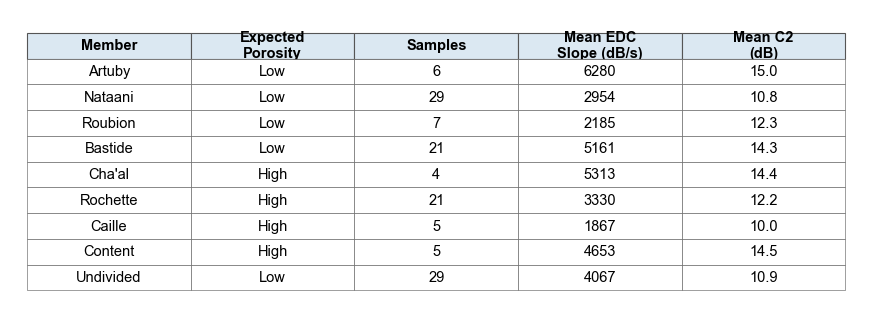

In [23]:
# ============================================================
# CLEAN POSTER SUMMARY TABLE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"

expected_porosity = {
    "Artuby": "Low",
    "Cha'al": "High",
    "Nataani": "Low",
    "Rochette": "High",
    "Roubion": "Low",
    "Caille": "High",
    "Content": "High",
    "Bastide": "Low",
    "Undivided": "Low"
}

member_order = [
    "Artuby", "Nataani", "Roubion", "Bastide", "Cha'al",
    "Rochette", "Caille", "Content", "Undivided"
]

summary = (
    df.assign(**{"EDC Slope Magnitude": -df["Slope (dB/s)"]})
      .groupby("Member")
      .agg(
          Samples=("Member", "count"),
          Mean_EDC=("EDC Slope Magnitude", "mean"),
          Mean_C2=("C2 (dB)", "mean")
      )
      .reset_index()
)

summary["Expected Porosity"] = summary["Member"].map(expected_porosity)

summary["Member"] = pd.Categorical(
    summary["Member"],
    categories=member_order,
    ordered=True
)

summary = summary.sort_values("Member")

summary["Mean EDC Slope"] = summary["Mean_EDC"].round(0).astype(int)
summary["Mean C2"] = summary["Mean_C2"].round(1)

summary_display = summary[
    ["Member", "Expected Porosity", "Samples", "Mean EDC Slope", "Mean C2"]
]

summary_display.columns = [
    "Member",
    "Expected\nPorosity",
    "Samples",
    "Mean EDC\nSlope (dB/s)",
    "Mean C2\n(dB)"
]

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.axis("off")

table = ax.table(
    cellText=summary_display.values,
    colLabels=summary_display.columns,
    loc="center",
    cellLoc="center",
    colLoc="center",
    bbox=[0.02, 0.04, 0.96, 0.88]
)

table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1.05, 1.75)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#555555")

    if row == 0:
        cell.set_facecolor("#dbe8f2")
        cell.set_text_props(weight="bold")
        cell.set_linewidth(0.8)
    else:
        cell.set_facecolor("white")
        cell.set_linewidth(0.4)

plt.savefig(
    "poster_summary_table_clean.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
    pad_inches=0.08
)

plt.savefig(
    "poster_summary_table_clean.pdf",
    bbox_inches="tight",
    transparent=True,
    pad_inches=0.08
)

plt.show()

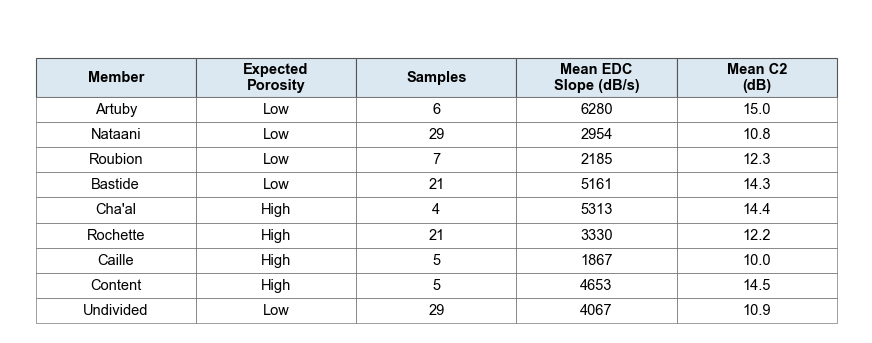

In [26]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.axis("off")

table = ax.table(
    cellText=summary_display.values,
    colLabels=summary_display.columns,
    loc="center",
    cellLoc="center",
    colLoc="center",
    bbox=[0.03, 0.03, 0.94, 0.82]   # left, bottom, width, height
)

table.auto_set_font_size(False)
table.set_fontsize(10.5)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#555555")

    if row == 0:
        cell.set_facecolor("#dbe8f2")
        cell.set_text_props(weight="bold", va="center")
        cell.set_linewidth(0.8)
        cell.set_height(0.16)
    else:
        cell.set_facecolor("white")
        cell.set_linewidth(0.4)
        cell.set_height(0.105)

plt.savefig(
    "poster_summary_table_clean.png",
    dpi=300,
    bbox_inches=None,
    transparent=True,
    pad_inches=0.2
)

plt.savefig(
    "poster_summary_table_clean.pdf",
    bbox_inches=None,
    transparent=True,
    pad_inches=0.2
)

plt.show()